# 1.Business Understanding
The goal of this project is to create a Machine learning predictive model to predict whether individuals received the H1N1 flu vaccine using data from the 2009 National H1N1 Flu Survey.Insights from these patterns can guide public health professionals in developing more effective vaccination strategies and identifying groups with lower,higher likelihood of getting vaccinated.By examining past vaccination patterns, the study aims to shed light on contemporary vaccination behaviors

## 2 .Problem Statement 
Vaccine reluctance remains a major obstacle to public health initiatives, as it can reduce vaccination rates and increase the risk of disease outbreaks. Gaining insight into the factors that influence individuals’ decisions to accept or decline vaccines is essential for developing strategies that encourage higher vaccination uptake. This project aims to use machine learning methods to predict whether individuals are likely to receive the H1N1 flu vaccine, using data collected from the National Flu Survey (NHFS 2009).
### 2.1 Project objectives
### 2.1.1 Main objectives.
To predict whether individuals received the H1N1 flu vaccine using demographic, behavioral, and health-related data
### 2.1.2 Specific objectives



1.Develop machine learning models that can predict whether individuals are likely to receive the H1N1 vaccine

2.Identify the main factors that influence vaccine acceptance.

3.Evaluate the performance of different machine learning models by comparing how well they predict vaccine uptake.

4.Use the results from the predictive models to generate insights that can help public health professionals and policymakers design strategies to improve vaccination uptake.

## 2.2 Stakeholders
1.Public Health Authorities.

2.Healthcare Providers i.e doctors,nurses.

3.Policymakers and Government Agencies

4.Health Insurance providers

## 3 Data Understanding

### Data source

This dataset originates from the National Flu Survey (NHFS) of 2009, a survey conducted to understand public behavior and attitudes regarding influenza vaccination, specifically targeting the H1N1 flu vaccine.

###  Importing libraries

In [1440]:
# Importing necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

#Machine learning libraries
from sklearn.model_selection import train_test_split  
from sklearn.preprocessing import StandardScaler    
from sklearn.compose import ColumnTransformer      
from sklearn.pipeline import Pipeline              
from sklearn.preprocessing import OneHotEncoder 
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier,VotingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV




In [1441]:
#loading the training set  dataset
training_features= pd.read_csv ('data/training_set_features.csv')
training_features

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,qufhixun,Non-MSA,0.0,0.0,NaN,NaN
26703,26703,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Rent,Employed,lzgpxyit,"MSA, Principle City",1.0,0.0,fcxhlnwr,cmhcxjea
26704,26704,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,...,NaN,Not Married,Own,NaN,lzgpxyit,"MSA, Not Principle City",0.0,0.0,NaN,NaN
26705,26705,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,...,"<= $75,000, Above Poverty",Married,Rent,Employed,lrircsnp,Non-MSA,1.0,0.0,fcxhlnwr,haliazsg


In [1442]:
training_features.isnull().sum()

respondent_id                      0
h1n1_concern                      92
h1n1_knowledge                   116
behavioral_antiviral_meds         71
behavioral_avoidance             208
behavioral_face_mask              19
behavioral_wash_hands             42
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_touch_face            128
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
health_insurance               12274
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
opinion_h1n1_sick_from_vacc      395
opinion_seas_vacc_effective      462
opinion_seas_risk                514
opinion_seas_sick_from_vacc      537
age_group                          0
education                       1407
race                               0
sex                                0
income_poverty                  4423
m

In [1443]:
#loading the training set labels
training_labels= pd.read_csv("data/training_set_labels.csv")
training_labels

,respondent_id,h1n1_vaccine,seasonal_vaccine
0,0,0,0
1,1,0,1
2,2,0,0
3,3,0,1
4,4,0,0
...,...,...,...
26702,26702,0,0
26703,26703,0,0
26704,26704,0,1
26705,26705,0,0


In [1444]:
training_labels.isnull().sum()

respondent_id       0
h1n1_vaccine        0
seasonal_vaccine    0
dtype: int64

In [1445]:
#loading the test set features
test_set_features= pd.read_csv("data/test_set_features.csv")
test_set_features

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,26707,2.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,"> $75,000",Not Married,Rent,Employed,mlyzmhmf,"MSA, Not Principle City",1.0,0.0,atmlpfrs,hfxkjkmi
1,26708,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Below Poverty,Not Married,Rent,Employed,bhuqouqj,Non-MSA,3.0,0.0,atmlpfrs,xqwwgdyp
2,26709,2.0,2.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,...,"> $75,000",Married,Own,Employed,lrircsnp,Non-MSA,1.0,0.0,nduyfdeo,pvmttkik
3,26710,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Married,Own,Not in Labor Force,lrircsnp,"MSA, Not Principle City",1.0,0.0,NaN,NaN
4,26711,3.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,lzgpxyit,Non-MSA,0.0,1.0,fcxhlnwr,mxkfnird
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26703,53410,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,NaN,NaN,NaN,NaN,dqpwygqj,"MSA, Principle City",1.0,1.0,NaN,NaN
26704,53411,3.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,...,Below Poverty,Married,Rent,Employed,qufhixun,Non-MSA,1.0,3.0,fcxhlnwr,vlluhbov
26705,53412,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Below Poverty,Not Married,Rent,Not in Labor Force,qufhixun,"MSA, Not Principle City",1.0,0.0,NaN,NaN
26706,53413,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,...,"<= $75,000, Above Poverty",Married,Own,Not in Labor Force,bhuqouqj,"MSA, Not Principle City",1.0,0.0,NaN,NaN


In [1446]:
test_set_features.isnull().sum()

respondent_id                      0
h1n1_concern                      85
h1n1_knowledge                   122
behavioral_antiviral_meds         79
behavioral_avoidance             213
behavioral_face_mask              19
behavioral_wash_hands             40
behavioral_large_gatherings       72
behavioral_outside_home           82
behavioral_touch_face            128
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
chronic_med_condition            932
child_under_6_months             813
health_worker                    789
health_insurance               12228
opinion_h1n1_vacc_effective      398
opinion_h1n1_risk                380
opinion_h1n1_sick_from_vacc      375
opinion_seas_vacc_effective      452
opinion_seas_risk                499
opinion_seas_sick_from_vacc      521
age_group                          0
education                       1407
race                               0
sex                                0
income_poverty                  4497
m

## Data Preparation.
The dataset underwent several preparatory steps to facilitate analysis.  Categorical columns were transformed using OneHotEncoder, generating new columns to represent each category. Missing values were filled using Iterative Imputer . Pipelines were utilized to streamline the preprocessing and modeling processes, reducing the risk of data leakage. Additionally, the dataset was split into training and testing sets to ensure the availability of a holdout set for evaluating the final model.

In [1447]:
# Merging features and labels on respondent_id
training_df = pd.merge(training_features, training_labels, on="respondent_id")
training_df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [1448]:
#dropping columns I don't need .
training_df= training_df.drop(columns=['opinion_seas_risk','employment_industry',
'opinion_seas_vacc_effective','opinion_seas_sick_from_vacc', 'seasonal_vaccine','doctor_recc_seasonal','employment_occupation'])

In [1449]:
training_df.info() #checking column names and datatypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  chronic_med_condition        25736 non-null  float64
 12  child_under_6_months         25887 non-null  float64
 13  health_worker   

## 5.Data analysis and processing

### Exploratory Data Analysis (EDA)
Here we analyze:

1.vaccine uptake distribution

2.effect of doctor recommendation

3.perception of vaccine effectiveness

4.risk perception

5.demographic factors

1. Analyzing the vaccine uptake distribution

In [1450]:
# Checking the  class balance of the target variable
y.value_counts(normalize=True)

h1n1_vaccine
0    0.787546
1    0.212454
Name: proportion, dtype: float64

78.75% of respondents did not receive the H1N1 vaccine.

21.25% of respondents received the H1N1 vaccine.

This indicates that the dataset is imbalanced, meaning one class occurs much more frequently than the other. In this case, the majority class is individuals who did not receive the vaccine, while the minority class is individuals who did receive the vaccine.

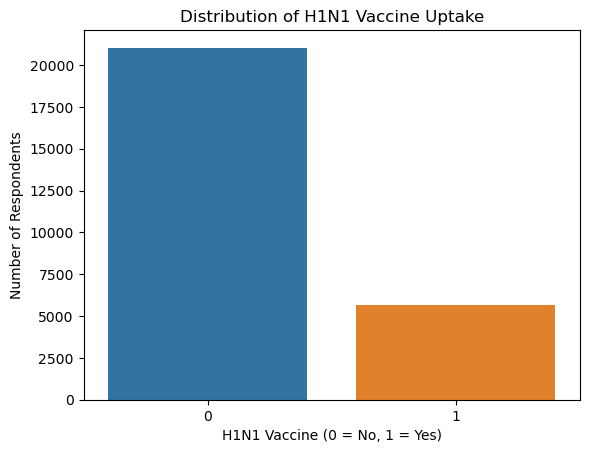

In [1451]:
# Plotting distribution of H1N1 vaccine uptake
sns.countplot(x="h1n1_vaccine", data=training_df)

plt.title("Distribution of H1N1 Vaccine Uptake")
plt.xlabel("H1N1 Vaccine (0 = No, 1 = Yes)")
plt.ylabel("Number of Respondents")

plt.show()

2.Checking the effect of Doctor's recommendation on H1N1 vaccine intake

In [1452]:
# Convert numeric categories to strings to avoid seaborn legend bug
training_df["h1n1_vaccine"] = training_df["h1n1_vaccine"].astype(str)
training_df["doctor_recc_h1n1"] = training_df["doctor_recc_h1n1"].astype(str)

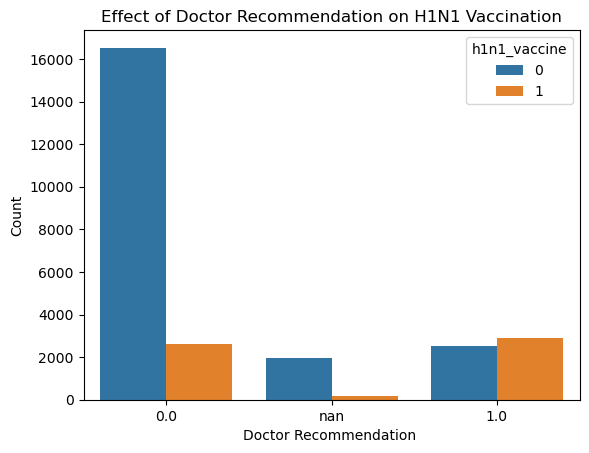

In [1453]:
sns.countplot(
    data=training_df,
    x="doctor_recc_h1n1",
    hue="h1n1_vaccine"
)

plt.title("Effect of Doctor Recommendation on H1N1 Vaccination")
plt.xlabel("Doctor Recommendation ")
plt.ylabel("Count")

plt.show()

This suggests that doctor recommendation plays a significant role in influencing vaccination behavior. Individuals are much more likely to receive the H1N1 vaccine when it is recommended by a healthcare professional.

3. Analyzing the perception of vaccine effectiveness

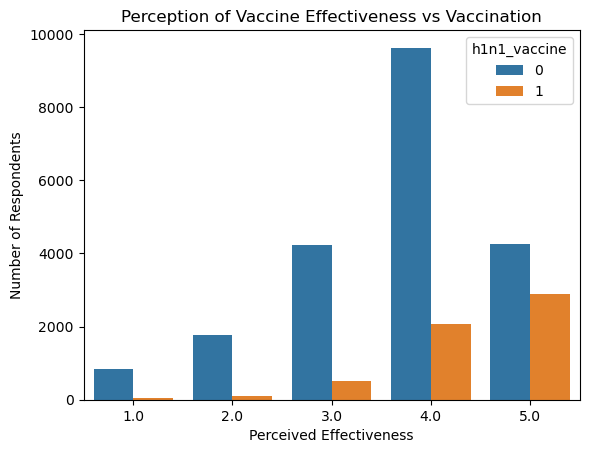

In [1454]:
sns.countplot(
    x="opinion_h1n1_vacc_effective",
    hue="h1n1_vaccine",
    data=training_df
)

plt.title("Perception of Vaccine Effectiveness vs Vaccination")
plt.xlabel("Perceived Effectiveness")
plt.ylabel("Number of Respondents")

plt.show()

From the graph perception of vaccine effectiveness influences vaccination decisions.Individuals who believe the vaccine is effective show higher vaccination rates.

4. Risk perception effect on H1N1 vaccine 

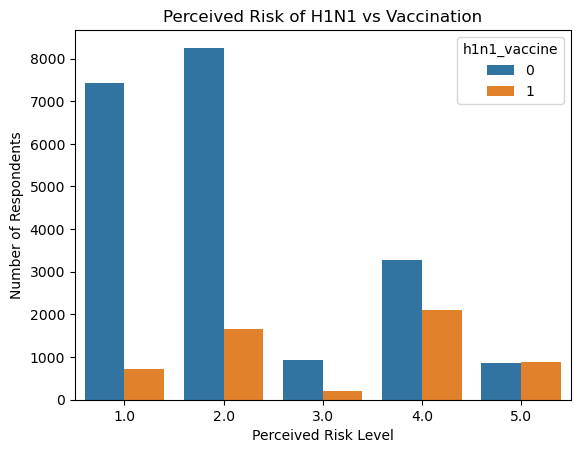

In [1455]:
sns.countplot(
    x="opinion_h1n1_risk",
    hue="h1n1_vaccine",
    data=training_df
)

plt.title("Perceived Risk of H1N1 vs Vaccination")
plt.xlabel("Perceived Risk Level")
plt.ylabel("Number of Respondents")

plt.show()

 From the above graph people who believe that H1N1 poses a higher health risk are more likely to receive the vaccine, while individuals who perceive the risk as low are less likely to get vaccinated. This suggests that risk perception influences vaccination decisions.

5. Analyzing how Demographic factors(Age group) affect H1N1 vaccine intake

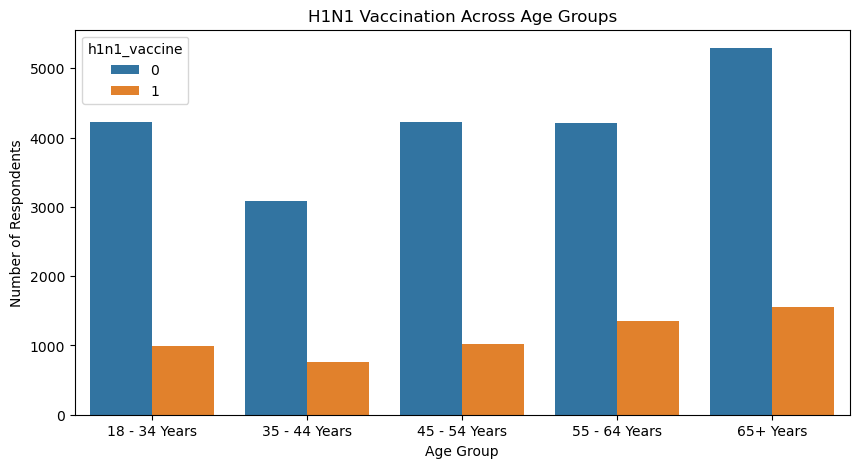

In [1456]:
plt.figure(figsize=(10,5))
age_order = ["18 - 34 Years", "35 - 44 Years", "45 - 54 Years", 
             "55 - 64 Years", "65+ Years"] ## Defining correct order of age groups

sns.countplot(
    x="age_group",
    hue="h1n1_vaccine",
    data=training_df,
    order=age_order
)

plt.title("H1N1 Vaccination Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Respondents")

plt.show()

From the graph Older individuals appear more likely to get vaccinated than younger individuals.

## 6.Data Cleaning

 In this section the data was first split then data cleaning was handled using a preprocessing pipeline to ensure consistency and prevent data leakage. Missing values were imputed (median for numerical and most frequent for categorical variables), numerical features were scaled, and categorical variables were encoded using one-hot encoding. A ColumnTransformer was used to apply these transformations efficiently to both training and test data.

In [1457]:
#Separating features from target
X = training_df.drop('h1n1_vaccine',axis=1)# dropping the target
y = training_df['h1n1_vaccine']

In [1458]:
#split the dataset
#This is done before cleaning to prevent leakage .
# This approach provides a more reliable evaluation of model performance.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)
X_train.shape

(21365, 30)

In [1459]:
#Defining column types
numeric_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Creating Pipelines
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

# Column transformer
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)])

# Transforming the data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 8. Get feature names
num_features = numeric_cols
cat_features = preprocessor.named_transformers_['cat']\
    .named_steps['encoder']\
    .get_feature_names_out(categorical_cols)

all_features = list(num_features) + list(cat_features)

# 9. Convert to DataFrames
X_train_df = pd.DataFrame(X_train_processed, columns=all_features, index=X_train.index)
X_test_df = pd.DataFrame(X_test_processed, columns=all_features, index=X_test.index)



In [1460]:
print("--- Unique Values in X_train ---")
for col in X_train.columns:
    unique_vals = X_train[col].unique()
    print(f"{col}: {len(unique_vals)} unique values")
    
    if len(unique_vals) < 15:
        print(f"  Values: {unique_vals}")
    print("-" * 20)

--- Unique Values in X_train ---
respondent_id: 21365 unique values
--------------------
h1n1_concern: 5 unique values
  Values: [ 1.  2.  3.  0. nan]
--------------------
h1n1_knowledge: 4 unique values
  Values: [ 2.  1.  0. nan]
--------------------
behavioral_antiviral_meds: 3 unique values
  Values: [ 0.  1. nan]
--------------------
behavioral_avoidance: 3 unique values
  Values: [ 1.  0. nan]
--------------------
behavioral_face_mask: 3 unique values
  Values: [ 0.  1. nan]
--------------------
behavioral_wash_hands: 3 unique values
  Values: [ 0.  1. nan]
--------------------
behavioral_large_gatherings: 3 unique values
  Values: [ 0.  1. nan]
--------------------
behavioral_outside_home: 3 unique values
  Values: [ 0.  1. nan]
--------------------
behavioral_touch_face: 3 unique values
  Values: [ 0.  1. nan]
--------------------
doctor_recc_h1n1: 3 unique values
  Values: ['0.0' '1.0' 'nan']
--------------------
chronic_med_condition: 3 unique values
  Values: [ 0.  1. nan]
-

## 7. Modeling
The goal of the modeling stage is to build predictive models that can estimate whether an individual is likely to receive the H1N1 vaccine


### Evaluator function
To assess the performance of the predictive models, we used different evaluation models. These metrics help determine how well the models can distinguish between individuals who received the H1N1 vaccine and those who did not. A reusable evaluation function was implemented to ensure a consistent and efficient evaluation process across all models

In [1461]:

#Creating a reusable evaluation function

def evaluate_model(model, X_test, y_test):

    # Convert targets to numeric
    y_test = np.array(y_test).astype(int)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    # Convert predictions to numeric
    y_pred = np.array(y_pred).astype(int)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    print("Accuracy:", accuracy)
    print("ROC-AUC:", auc)

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap="Blues",
        annot_kws={"size":14, "color":"black"},
        xticklabels=['Not Vaccinated','Vaccinated'],
        yticklabels=['Not Vaccinated','Vaccinated']
    )

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.2f})")
    plt.plot([0,1],[0,1],'k--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()

    plt.show()

### Creating logistic regression model

In [1462]:
# Modelling the pipeline
#We use logistic regression as the baseline model because it is used for binary classification
logreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42,
        solver='liblinear'))])


In [1463]:
logreg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['respondent_id',
                                                   'h1n1_concern',
                                                   'h1n1_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'behavioral_face_mask',
                                                   'behavioral_wash_hands',
                                                   'behavioral_large_gatherings',
                                                   'behavioral...
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['doctor_recc_h1n1',
                                                   'age_group', 'education',
                                                   'race', 'sex',
                                                   'income_poverty',
                                                   'marital_status',
                                                   'rent_or_own',
                                                   'employment_status',
                                                   'hhs_geo_region',
                                                   'census_msa'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42, solver='liblinear'))])

Accuracy: 0.7660052414825907
ROC-AUC: 0.8190121561609609

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.78      0.84      4207
           1       0.47      0.71      0.56      1135

    accuracy                           0.77      5342
   macro avg       0.69      0.75      0.70      5342
weighted avg       0.82      0.77      0.78      5342



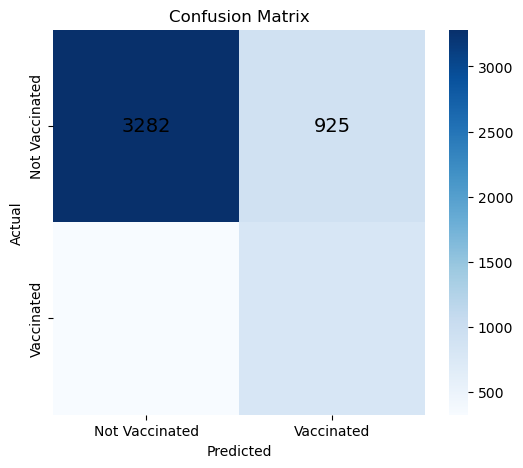

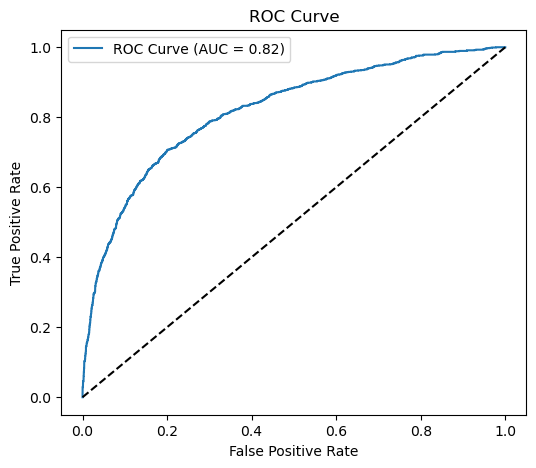

In [1464]:
evaluate_model(logreg_pipeline, X_test, y_test)

The ROC curve shows that the Logistic Regression model performs well in distinguishing between individuals who received the H1N1 vaccine and those who did not. The curve lies well above the random baseline. This suggests the model is effective as a baseline model for predicting H1N1 vaccination uptake.

The Logistic Regression model was able to correctly predict whether a person received the H1N1 vaccine about 77% of the time. The model is particularly good at identifying people who did not take the vaccine, but it is less accurate when predicting those who did take the vaccine. However, the ROC-AUC score of 0.82shows that the model does a good overall job of distinguishing between vaccinated and non-vaccinated individuals. These results indicate that the model performs reasonably well as a baseline model, but there is room for improvement using more advanced models.

In [1465]:
# Visualizing prediction correctness
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_log,
    "Probability": y_prob_log})

results.head(10)

,Actual,Predicted,Probability
0,1,1,0.562019
1,1,1,0.965627
2,0,0,0.077634
3,0,1,0.881121
4,0,0,0.236211
5,0,0,0.331676
6,0,1,0.625857
7,1,1,0.697327
8,0,0,0.087826
9,0,0,0.220903


The model performs well at identifying people who did not receive the vaccine, correctly classifying many of them. It also identifies a good number of vaccinated individuals, although some people are incorrectly predicted as vaccinated when they are not. Overall, the model shows reasonably good performance but still makes some prediction errors.

### Creating the Random forest model

In [1466]:
rf_pipeline= RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42)


In [1467]:
rf_pipeline.fit(X_train_df, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

Accuracy: 0.832459752901535
ROC-AUC: 0.817983243786054

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.95      0.90      4207
           1       0.68      0.39      0.50      1135

    accuracy                           0.83      5342
   macro avg       0.77      0.67      0.70      5342
weighted avg       0.82      0.83      0.81      5342



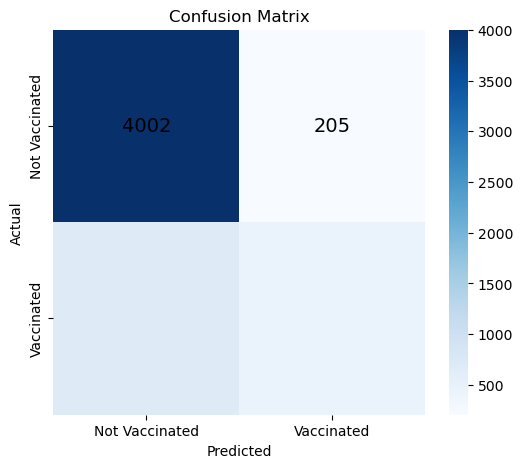

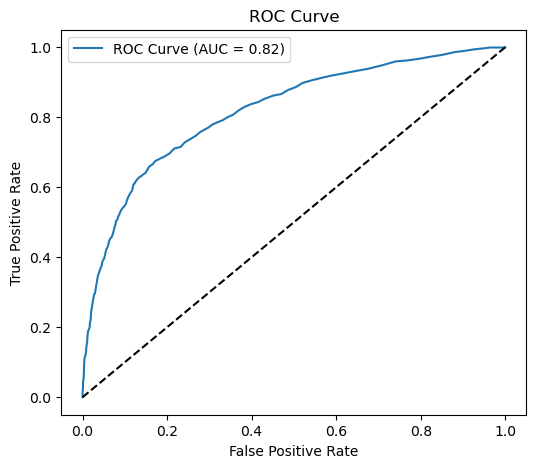

In [1468]:
evaluate_model(rf_pipeline, X_test_df, y_test)

The Random Forest model performs very well at identifying individuals who did not receive the vaccine, correctly predicting a large number of these cases. However, it struggles more with identifying people who actually received the vaccine, missing some vaccinated individuals. Overall, the model shows strong predictive ability but still makes some classification errors.

The ROC curve for the Random Forest model shows strong predictive performance. The curve lies well above the random baseline and moves toward the top-left corner, indicating that the model is effective at distinguishing between individuals who received the H1N1 vaccine and those who did not

The Random Forest model identified several key factors influencing H1N1 vaccination. The most important predictor was whether a doctor recommended the vaccine, suggesting that medical advice plays a critical role in vaccination decisions. Perceived risk of H1N1 infection and belief in vaccine effectiveness were also strong predictors. Additionally, individuals who expressed higher concern about H1N1 or had greater knowledge about the disease were more likely to get vaccinated

### Adding Ensemble model

Accuracy: 0.8244103332085362
ROC-AUC: 0.8246065661489295

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      4207
           1       0.59      0.59      0.59      1135

    accuracy                           0.82      5342
   macro avg       0.74      0.74      0.74      5342
weighted avg       0.82      0.82      0.82      5342



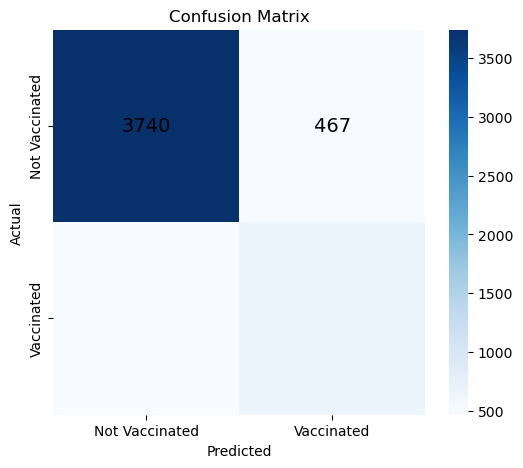

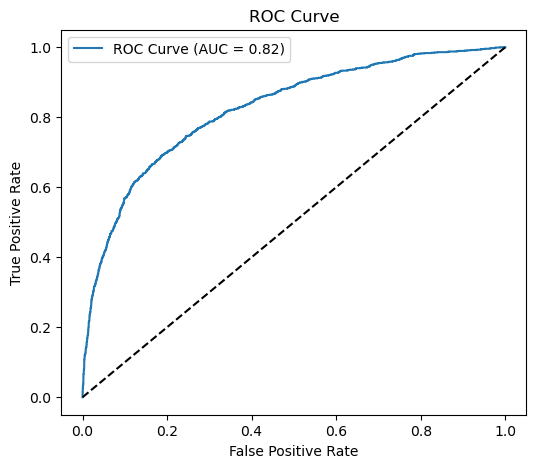

In [1469]:
# creating an Ensemble model
ensemble_model = VotingClassifier(
    estimators=[
        ('lr', logreg),
        ('rf', rf)
    ],
    voting='soft')
# Adding the model to pipeline
ensemble_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ensemble_model)])

# Training the model 
ensemble_pipeline.fit(X_train, y_train)

# Evaluating  the model
evaluate_model(ensemble_pipeline, X_test, y_test)


The ensemble model provides strong overall prediction performance, especially for identifying those who did not receive the vaccine.It achieved an accuracy of 82%

## 8 Findings

Two models were developed to predict whether individuals received the H1N1 vaccine: Logistic Regression (baseline model) and Random Forest (advanced model).

The Logistic Regression model achieved an accuracy of approximately 77% and an ROC-AUC score of about 0.82, indicating good overall performance in distinguishing between vaccinated and non-vaccinated individuals. The model performed reasonably well at identifying vaccinated individuals but produced a relatively higher number of false positive predictions.

The Random Forest model demonstrated strong predictive capability with an accuracy of 83% and an ROC-AUC pf about 0.82.   The model performed well compared to logistic regression.

Overall, both models performed well, but they showed different strengths. Random forest provided better balance in identifying vaccinated individuals.

## 9.Recommendations

Based on the model comparison, Random forest is recommended as the preferred model for this analysis because it provides a better balance between identifying vaccinated and non-vaccinated individuals while maintaining strong overall performance. 

The analysis also revealed that doctor recommendation, perceived risk of H1N1 infection, and belief in vaccine effectiveness were among the most important factors influencing vaccination uptake. Public health initiatives should therefore focus on strengthening healthcare provider recommendations and increasing public awareness about the risks of H1N1 and the effectiveness of the vaccine to improve vaccination rates.

In future , analyzing more recent flu survey data and applying additional feature engineering techniques could help improve the accuracy of the predictive models. Furthermore, extending the analysis to include seasonal flu vaccination status may offer a broader understanding of individuals’ vaccination behavior and the factors influencing vaccine uptake.

## 10 .Conclusions
The findings highlight the need to address people’s health concerns and support better awareness to encourage higher vaccination uptake. Public health authorities can use the factors identified in this analysis to design more effective vaccination campaigns and communication strategies aimed at improving public confidence in vaccines.